# <span style="color:#CC5500">Alluvial Fan Generator and Catchment Incision in a Simulated Mountainous Landscape</span>

### <span style="color:#654321">Shanti Penprase (Dartmouth College), Erica Scarpitti (Vanderbilt University), Zhilin Shi (Indiana University Bloomington), Tahmida Sarker Muna (Louisiana State University)</span>

This notebook generates an artificial mountainous landscape and develops alluvial fans flowing from the range to a plateau below. It uses the `Landlab` library components including the `SPACE` component. 

The model initially sets up a mountain range sloping towards a flat plain with a constant uplift rate. The mountain range has customizable soil thickness and slope. The model can then run uplift over a preset timescale to develop allvuial fans.


**The model run automatically generates time slice figures for each model run and includes an optional .gif maker at the end to animate the run.**

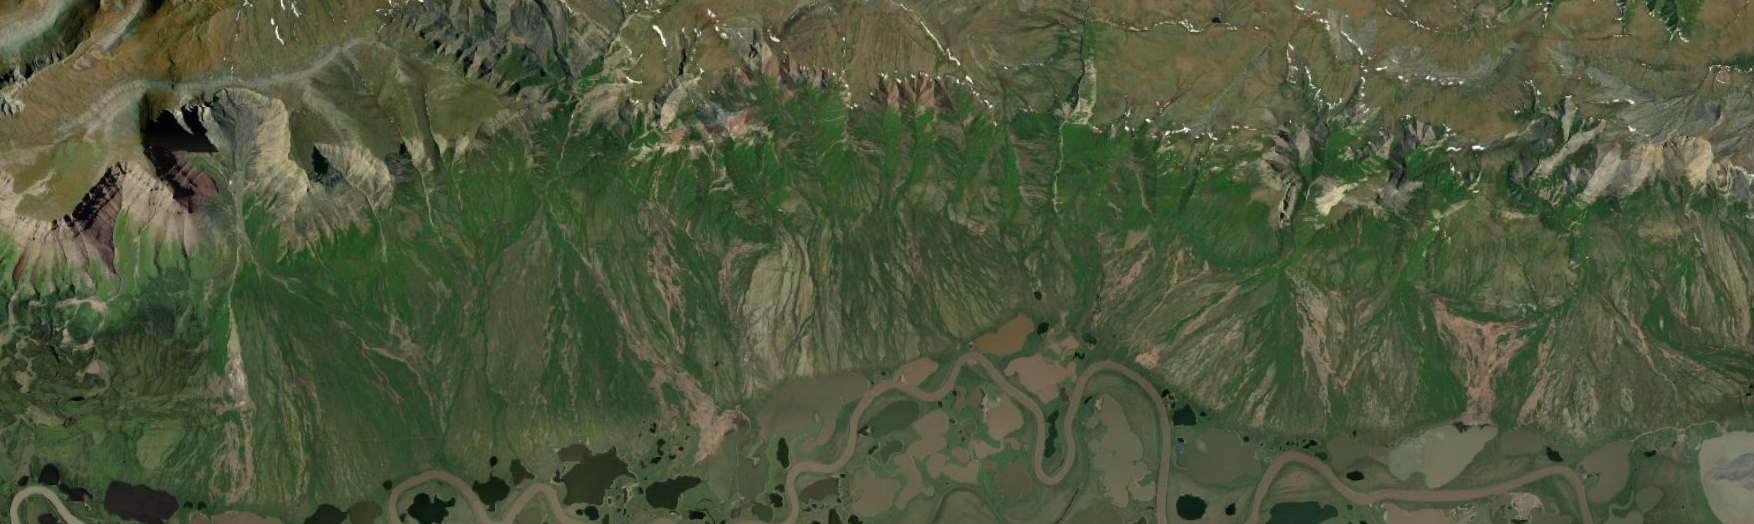

---


### Import packages

In [1]:
import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid  # Grid utility
from landlab import imshow_grid  # For plotting results; optional
from landlab.components import Space  # SPACE model
from landlab.components import DepressionFinderAndRouter, FlowAccumulator


from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler

import os
os.makedirs("frames", exist_ok=True)

### Set up grid

In [2]:
num_rows = 50
num_cols = 100
dxy = 50

mg = RasterModelGrid((num_rows, num_cols), xy_spacing=dxy)

# adding fields
z = mg.add_zeros('topographic__elevation', at='node', clobber=True)

# soil depth
soil = mg.add_zeros("soil__depth", at="node", clobber=True)

# bedrock elevation
bedrock = mg.add_field("bedrock__elevation", z - soil, at="node", clobber=True)

In [3]:
# set random roughness of terrain 
np.random.seed(42)

#define where the mountain front is - this can be changed if we want more area for the lowland 
front_y = 0.5 * mg.y_of_node.max()

#initial slopes 
basin_slope = 0.01  #can change these
upland_slope = 0.05

# initiate drainage 
roughness = 0.05 * np.random.rand(mg.number_of_nodes)

# ID upland nodes 
upland = mg.y_of_node >= front_y

#create the distinct highland/lowland 
z[upland] += (50.0 + upland_slope * (mg.y_of_node[upland] - front_y))
z[:] += roughness 
# z[:] = 0.02 * np.maximum(mg.node_y - mountain_front, 0.0)

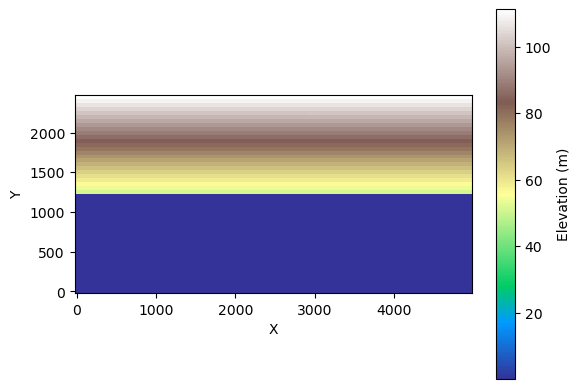

In [4]:
imshow_grid(mg,"topographic__elevation", cmap="terrain",
    colorbar_label="Elevation (m)")

In [5]:
# boundary conditons so that only the bottom is open 
mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=False, left_is_closed=True, right_is_closed=True, top_is_closed=True)

### Preview Starting Topography

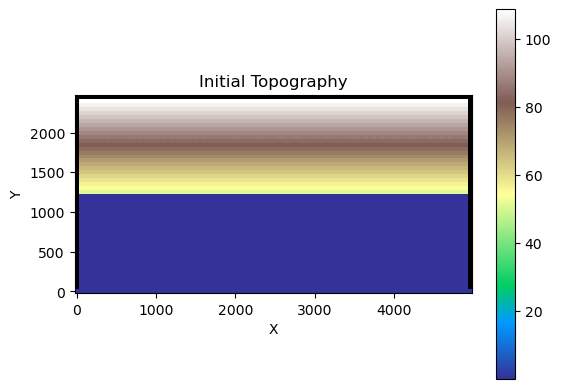

In [6]:
# Let's see our initial topography 
imshow_grid(mg, "topographic__elevation", cmap="terrain")
plt.title("Initial Topography")
plt.show()

-----
## <span style="color:red">Set Initial Space Parameters</span>

In [7]:
# Instantiate flow router
fr = FlowAccumulator(mg, flow_director="FlowDirectorD8", depression_finder="DepressionFinderAndRouter")

# Instantiate SPACE model with chosen parameters
sp = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=5.0,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
    solver= 'adaptive'
)


In [8]:
# 1. Define which nodes are upland and which are lowland 
upland_core_nodes = mg.core_nodes[mg.y_of_node[mg.core_nodes] >= front_y]

basin_core_nodes = np.where(mg.y_of_node < front_y)[0]

-----
## <span style="color:red">Set Uplift, Timestep, etc. for model run</span>

In [9]:
#2. Set up uplift, time step, and total run time - Able to change and mess with 
uplift_rate = 0.002 # m/yr
timestep = 10 #years
run_time = 5000 #years
count = 0 #set timestep count to zero 
n_steps = int(run_time / timestep) 

-----
## <span style="color:black">Run the model</span>

In [10]:
#4. The loop that incorporates uplift and sed flux... 



for count in range(n_steps):
    
    uplift_amount = uplift_rate * timestep

    #Upland cores only 
    bedrock[upland_core_nodes] += uplift_amount
    z[upland_core_nodes] += uplift_amount
    
    fr.run_one_step()
    
    
    # Erode, transport, and deposit sediment to lowland surface 
    sp.run_one_step(dt=timestep)
    

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

   
    plt.sca(axes[0])
    imshow_grid(mg, "topographic__elevation", 
                cmap="terrain", 
                grid_units=["m", "m"], 
                vmin=0, vmax=10, 
                colorbar_label ="Topographic Elevation (m)", 
                shrink = 0.5, 
                plot_name = f"{timestep * count} years")
    
    # Activate and plot on the second axis
    plt.sca(axes[1])
    imshow_grid(mg, "topographic__elevation", 
                grid_units=["m", "m"], 
                cmap="terrain", 
                vmin=0, vmax=2, 
                colorbar_label ="Topographic Elevation (m)", 
                shrink=0.5, 
                plot_name = f"{timestep * count} years")
   
    plt.savefig(f"frames/frame_{count:03d}.png", dpi=100)
    plt.close(fig)



    plt.show()

-----
## <span style="color:black">Convert the outputs to gif</span>

In [11]:
import imageio.v3 as iio
import glob

In [12]:
fp_in = "frames/*.png"
fp_out = "animated_output.gif"

img_paths = sorted(glob.glob(fp_in))

# Read images
images = [iio.imread(f) for f in img_paths]

# Save the compiled GIF
iio.imwrite(fp_out, images, duration=200, loop=0)

### Fan before fire

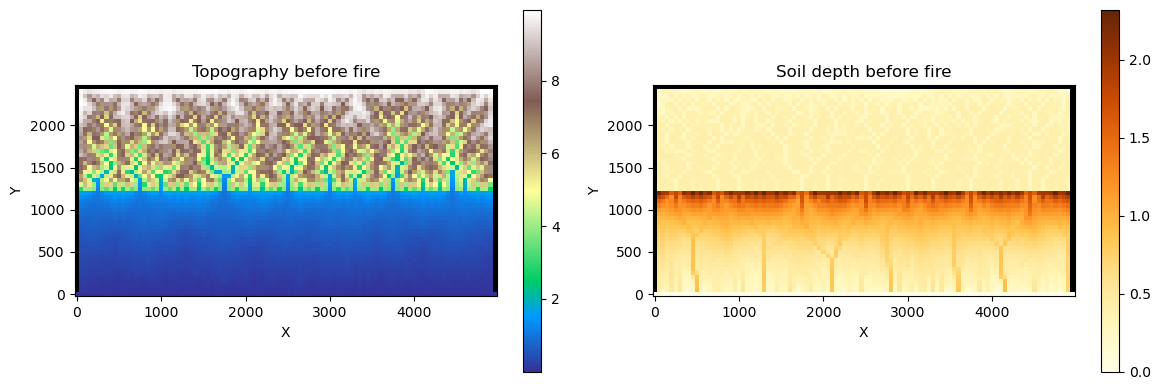

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.sca(axes[0])
imshow_grid(mg, "topographic__elevation", cmap="terrain")
axes[0].set_title("Topography before fire")

plt.sca(axes[1])
imshow_grid(mg, "soil__depth", cmap="YlOrBr")
axes[1].set_title("Soil depth before fire")
plt.tight_layout()
plt.show()


In [14]:
import imageio.v3 as iio
import glob

fp_in = "frames/*.png"
fp_out = "animated_output.gif"

img_paths = sorted(glob.glob(fp_in))

# Read images
images = [iio.imread(f) for f in img_paths]

# Save the compiled GIF
iio.imwrite(fp_out, images, duration=200, loop=0)

## Wildfire part - effect on sediment yield

https://github.com/espin-2021/firescapes

### Defining the functions

#### Description of the Burner
Wilfires are produced in the Burner with perfectly random locations. Their magnitudes and frequencies of occurrence are described as independent random variables, given by the joint distribution
$$ f(s,t) = \lambda k e^{-k t - \lambda s} $$
Here, $s$ is the areal extent of a given fire and $t$ is the time at which it occurs. The average fire size is $1/\lambda$, while the average time between fires is $1/k$.

#### Description of the Erodibility Stepper
The impact of fires on hillslope erosion is represented by an erodibility increase in burned areas. If the baseline erodibility in the absence of fire is $K_0$, the erodibility immediately after a fire is given as
$$ K_s(t) = K_0 + (1-e^{-t/\tau})K_b$$
Here, $K_b$ is the erodibility "boost" following fire, and $\tau$ is the timescale over which the erodiblity returns to its baseline $K_0$. This timescale will be related to the period of vegetation re-establishment.
The Erodibility Stepper computes this erodibility evolution as wildfires occur.

In [15]:
class ErodibilityStepper:
    """
    This class is initialized by a decay_constant, describing the rate at which
    the erodibility of burned areas recovers, and a baseline erodibility value Ksed0.
    """
    def __init__(self, decay_time=1, K_sed0=1):
        self.decay_time = decay_time
        self.K_sed0 = K_sed0

    def stepper(self, space, dt):
        """
        Modifies the erodibility of `space` on each gridcell by one timestep,
        by the equation dK/dt = -decay_const*(Ksed-Ksed0) -- decay of the
        erodibility toward its equilibrium value Ksed_0. Solved with a
        simple Euler method.
        """
        dK_sed = -(space.K_sed - self.K_sed0) * dt / self.decay_time
        space.K_sed += dK_sed


class Burner:
    """
    Initialized by a fire frequency, mean fire radius in units of the grid size,
    and the amount K_sed_boost by which the sediment erodibility is increased
    by fire. The method `fire` now draws a Poisson-distributed *number* of
    fires each timestep (mean = fire_freq * dt * fires_scale) instead of a
    single yes/no event, so multiple fires can occur in one step. Each fire
    gets its own random center and radius. Returns the union of all nodes
    burned this step, so it can be plotted on the grid.
    """
    def __init__(self, fire_freq=1, R_fire_mean=1, K_sed_boost=1, dt=1, dx=1,
                 fires_scale=10):
        self.fire_freq = fire_freq
        self.R_fire_mean = R_fire_mean
        self.K_sed_boost = K_sed_boost
        self.dt = dt
        self.dx = dx
        self.fires_scale = fires_scale  # bump this up to get more fires/step
        self.fireTimes = []
        self.fireSizes = []

    @property
    def R_fire(self):
        """choose a random fire size from an exponential distribution
        having mean size R_fire_mean"""
        return np.random.exponential(self.R_fire_mean)

    def fire(self, space, grid, t):
        """Generates 0+ fires at random locations within the grid this step."""
        lam = self.fire_freq * self.dt * self.fires_scale
        n_fires = np.random.poisson(lam)
        if n_fires == 0:
            return np.array([], dtype=int)

        K_sed = space.K_sed
        burned_this_step = []

        for _ in range(n_fires):
            center = np.random.choice(K_sed.size)
            changed_nodes = self._within(center, space, grid)
            K_sed[changed_nodes] += self.K_sed_boost

            s1 = grid.x_of_node[center]
            s2 = grid.y_of_node[center]
            A = len(changed_nodes) * self.dx**2 / 1e6  # km^2
            print(r'fire at ({},{}) of area {} square km, t={}.'.format(
                round(s1, 0), round(s2, 0), round(A, 2), t))

            self.fireTimes.append(t)
            self.fireSizes.append(A)
            burned_this_step.append(changed_nodes)

        space.K_sed = K_sed
        return np.unique(np.concatenate(burned_this_step))

    def _within(self, center, space, grid):
        """return all nodes within distance R_fire of center within grid"""
        centerPoint = (grid.x_of_node[center], grid.y_of_node[center])
        mask = grid.calc_distances_of_nodes_to_point(centerPoint) < self.R_fire
        return np.arange(mask.size)[mask]


### Set the fire parameters

In [16]:
decay_time_fire = timestep * 15          # "decay_time = dt_sp*15"
R_fire_mean = num_cols * dxy / 10        # "grid_dim[0]*dx/10"
fire_freq = 1 / (30 * timestep)          # "1/(30*dt_sp)"
K_sed_boost = 5 * 0.01                   # "5*K_sed0"


In [17]:
import os
os.makedirs("frames_fire", exist_ok=True)

# use the fan grid from Stage 1 (do NOT reset mg here)
z = mg.at_node["topographic__elevation"]
soil = mg.at_node["soil__depth"]
bedrock = mg.at_node["bedrock__elevation"]

K_sed_field = np.ones(mg.number_of_nodes) * 0.01
sp.K_sed = K_sed_field

es = ErodibilityStepper(decay_time=decay_time_fire, K_sed0=0.01)
burner = Burner(
    fire_freq=fire_freq,
    R_fire_mean=R_fire_mean,
    K_sed_boost=K_sed_boost,
    dt=timestep,
    dx=dxy,
    fires_scale=10,
)

outlet_row = mg.core_nodes[
    mg.y_of_node[mg.core_nodes] == mg.y_of_node[mg.core_nodes].min()
]

n_steps_fire = 150
sedflux_fire = np.zeros(n_steps_fire)
t_fire = np.zeros(n_steps_fire)

burned_field = mg.add_zeros("burned_this_step", at="node", clobber=True)
times_burned = mg.add_zeros("times_burned", at="node", clobber=True)

for count in range(n_steps_fire):
    uplift_amount = uplift_rate * timestep
    bedrock[upland_core_nodes] += uplift_amount
    z[upland_core_nodes] += uplift_amount

    fr.run_one_step()
    sp.run_one_step(dt=timestep)
    es.stepper(sp, dt=timestep)

    burned_nodes = burner.fire(sp, mg, count * timestep)

    burned_field[:] = 0
    if burned_nodes.size > 0:
        burned_field[burned_nodes] = 1
        times_burned[burned_nodes] += 1

    sedflux_fire[count] = mg.at_node["sediment__flux"][outlet_row].sum()
    t_fire[count] = (count + 1) * timestep

    fig, ax = plt.subplots(figsize=(7, 4))
    imshow_grid(mg, "times_burned", cmap="hot",
                plot_name=f"Cumulative burn map, t={count * timestep} yr")
    plt.savefig(f"frames_fire/f_{count:03d}.png")
    plt.close(fig)

print(f"fires that occurred: {len(burner.fireTimes)}")


fire at (750.0,400.0) of area 0.15 square km, t=20.
fire at (800.0,850.0) of area 0.46 square km, t=50.
fire at (2300.0,250.0) of area 0.11 square km, t=120.
fire at (3100.0,450.0) of area 0.11 square km, t=180.
fire at (2050.0,300.0) of area 0.01 square km, t=250.
fire at (1600.0,2350.0) of area 0.6 square km, t=260.
fire at (3650.0,400.0) of area 0.25 square km, t=340.
fire at (250.0,2250.0) of area 0.74 square km, t=400.
fire at (3450.0,600.0) of area 2.69 square km, t=400.
fire at (4000.0,800.0) of area 0.73 square km, t=420.
fire at (2750.0,350.0) of area 1.97 square km, t=510.
fire at (3250.0,1900.0) of area 0.3 square km, t=550.
fire at (1550.0,100.0) of area 1.48 square km, t=560.
fire at (3800.0,1100.0) of area 0.0 square km, t=600.
fire at (2100.0,450.0) of area 0.09 square km, t=690.
fire at (650.0,1550.0) of area 0.76 square km, t=690.
fire at (1800.0,2400.0) of area 0.07 square km, t=690.
fire at (1550.0,550.0) of area 6.13 square km, t=840.
fire at (2650.0,100.0) of area 

### Animate the burn map


In [18]:
import imageio.v3 as iio
import glob

img_paths = sorted(glob.glob("frames_fire/*.png"))
images = [iio.imread(f) for f in img_paths]
iio.imwrite("fire_burn_map.gif", images, duration=200, loop=0)
print(f"saved fire_burn_map.gif from {len(images)} frames")


saved fire_burn_map.gif from 150 frames


### Compare sediment yield to fire timing

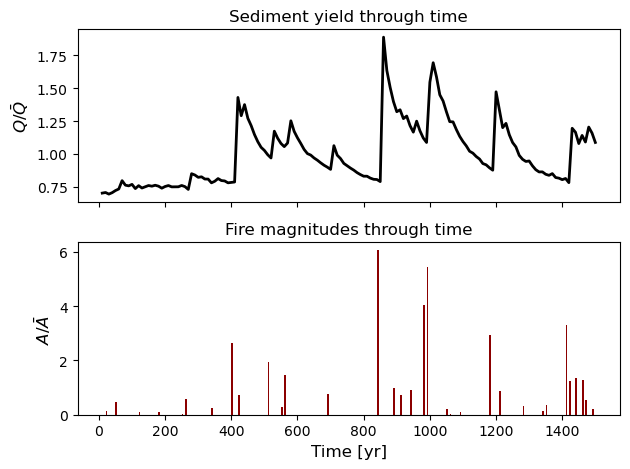

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t_fire, sedflux_fire / np.mean(sedflux_fire), lw=2, color="black")
if len(burner.fireSizes) > 0:
    ax2.bar(burner.fireTimes, np.array(burner.fireSizes) / np.mean(burner.fireSizes),
            width=5, align="edge", lw=2, color="darkred")

plt.xlabel("Time [yr]", fontsize=12)
ax1.set_ylabel(r"$Q/\bar{Q}$", fontsize=12)
ax2.set_ylabel(r"$A/\bar{A}$", fontsize=12)
ax1.set_title("Sediment yield through time", fontsize=12)
ax2.set_title("Fire magnitudes through time", fontsize=12)
plt.tight_layout()
plt.show()
